<a href="https://colab.research.google.com/github/BLOODHACKER123/BLOODHACKER123/blob/main/AI_Fruit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt


In [11]:
train_dir = '/content/drive/My Drive/AI_Fruit_Classifier/train'

In [12]:
train_datagen =ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary'
)

Found 35 images belonging to 2 classes.


In [16]:
model=keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(512,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [23]:
history=model.fit(train_generator,epochs=15)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 710ms/step - accuracy: 0.5714 - loss: 1.3626
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 921ms/step - accuracy: 0.4286 - loss: 6.5903
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - accuracy: 0.6571 - loss: 0.8746
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step - accuracy: 0.5714 - loss: 1.2232
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - accuracy: 0.6857 - loss: 0.5034
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 0.7143 - loss: 0.5324
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step - accuracy: 0.9714 - loss: 0.3352
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.2879
Epoch 9/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 1.0000 - loss: 0.1536
Epoch 10/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 1.0000 - loss: 0.0769
Epoch 11/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 960ms/step - accuracy: 0.9714 - loss: 0.0792
Epoch 12/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 668ms/step - accuracy: 1.0000 - loss: 0.021

In [29]:
apple_path = '/content/drive/My Drive/AI_Fruit_Classifier/test/apple.jpg'
mango_path = '/content/drive/My Drive/AI_Fruit_Classifier/test/mango.jpg'

In [25]:
class_labels = list(train_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


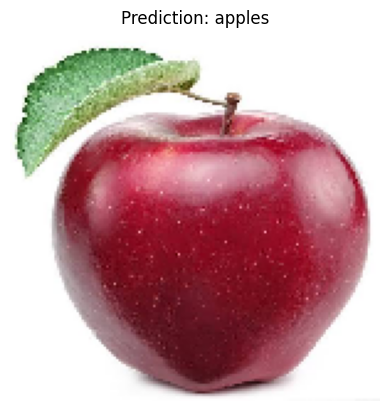

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


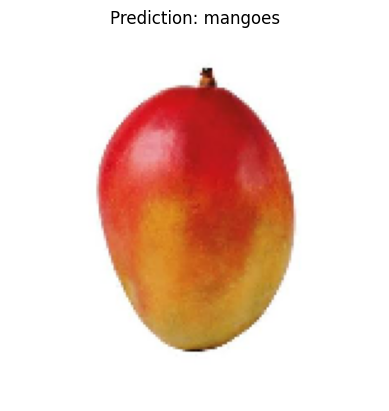

In [30]:
def predict_image(image_path):
    img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
    img_array =keras.preprocessing.image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array/=255.0
    prediction = model.predict(img_array)

    plt.imshow(img)
    plt.axis('off')


    if prediction[0] >= 0.5:
       predicted_class = class_labels[1]
    else:
       predicted_class = class_labels[0]

    plt.title(f"Prediction: {predicted_class}")
    plt.show()

predict_image(apple_path)
predict_image(mango_path)